In [ ]:
import numpy as np
from PIL import Image, ImageDraw, ImageFilter
import random
import os
import json
from tqdm import tqdm
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE         = '/content/drive/MyDrive/trazos'
DATASET_BASE = os.path.join(BASE, 'dataset', 'fase3_entrenamiento')

estructura = {
    'tuberias_sinteticas' : ['train', 'val', 'test'],
    'tuberias_con_ruido'  : ['train', 'val', 'test'],
}

for carpeta, splits in estructura.items():
    for split in splits:
        for sub in ['inputs', 'masks']:
            path = os.path.join(DATASET_BASE, carpeta, split, sub)
            os.makedirs(path, exist_ok=True)

os.makedirs(os.path.join(BASE, 'modelos', 'fase3'), exist_ok=True)

print("✅ Estructura Fase 3 creada")

Mounted at /content/drive
✅ Estructura Fase 3 creada


In [ ]:
def mostrar_estructura(base, nivel=0, max_nivel=5):
    try:
        items = sorted(os.listdir(base))
        for item in items:
            print('    ' * nivel + f'📁 {item}')
            ruta = os.path.join(base, item)
            if os.path.isdir(ruta):
                mostrar_estructura(ruta, nivel + 1, max_nivel)
    except:
        pass

mostrar_estructura(os.path.join(BASE, 'dataset', 'fase3_entrenamiento'))

📁 tuberias_con_ruido
    📁 test
        📁 inputs
        📁 masks
    📁 train
        📁 inputs
        📁 masks
    📁 val
        📁 inputs
        📁 masks
📁 tuberias_sinteticas
    📁 test
        📁 inputs
        📁 masks
    📁 train
        📁 inputs
        📁 masks
    📁 val
        📁 inputs
        📁 masks


In [ ]:
IMG_SIZE   = 256
TRAIN_N    = 1000
VAL_N      = 200
TEST_N     = 200
BG_COLOR   = 0
LINE_COLOR = 255

# ── Grosor variable — simula distintos diámetros ───────
def grosor_tuberia():
    return random.randint(4, 12)

# ── Color realista de tubería ──────────────────────────
def color_tuberia():
    """
    Colores típicos de tuberías industriales:
    grises, metálicos, blancos, amarillos, verdes.
    """
    paleta = [
        (180, 180, 180),   # gris metálico
        (200, 200, 200),   # gris claro
        (220, 210, 180),   # beige industrial
        (160, 160, 160),   # gris oscuro
        (210, 200, 170),   # crema
        (190, 190, 200),   # gris azulado
    ]
    base = random.choice(paleta)
    # pequeña variación para que no sean idénticos
    return tuple(max(0, min(255, c + random.randint(-15, 15))) for c in base)


# ── Tramo recto ────────────────────────────────────────
def dibujar_tramo(draw_img, draw_mask, x0, y0, x1, y1, grosor, color):
    """
    Dibuja un tramo recto de tubería.
    En la imagen: con grosor y color realista.
    En la mask: línea central fina (eje del trazo).
    """
    draw_img .line([(x0,y0),(x1,y1)], fill=color,      width=grosor)
    draw_mask.line([(x0,y0),(x1,y1)], fill=LINE_COLOR,  width=2)


# ── Sombra proyectada por tubería ──────────────────────
def dibujar_sombra(draw_img, x0, y0, x1, y1, grosor):
    """
    Las tuberías proyectan sombra en la pared.
    Se dibuja SOLO en la imagen, no en la mask.
    Offset de la sombra respecto al tubo.
    """
    offset = grosor // 2 + 2
    color_sombra = (15, 15, 15)
    draw_img.line(
        [(x0+offset, y0+offset),(x1+offset, y1+offset)],
        fill=color_sombra,
        width=grosor + 2
    )


# ── Abrazadera / soporte ───────────────────────────────
def dibujar_abrazadera(draw_img, x, y, grosor):
    """
    Pequeño rectángulo que representa el soporte
    que fija la tubería a la pared. Solo en imagen.
    """
    ancho  = grosor + 6
    alto   = grosor + 4
    color  = (100, 100, 100)
    draw_img.rectangle([
        (x - ancho//2, y - alto//2),
        (x + ancho//2, y + alto//2)
    ], outline=color, width=2)

print("✅ Funciones base definidas")

✅ Funciones base definidas


In [ ]:
def generar_tramo_recto(draw_img, draw_mask):
    """
    Tubería recta horizontal o vertical.
    Con sombra y abrazaderas opcionales.
    """
    grosor = grosor_tuberia()
    color  = color_tuberia()
    orient = random.choice(['horizontal', 'vertical'])

    if orient == 'horizontal':
        y  = random.randint(30, IMG_SIZE - 30)
        x0 = random.randint(10, 60)
        x1 = random.randint(IMG_SIZE - 60, IMG_SIZE - 10)
        dibujar_sombra(draw_img, x0, y, x1, y, grosor)
        dibujar_tramo(draw_img, draw_mask, x0, y, x1, y, grosor, color)
        # Abrazaderas cada cierta distancia
        for ax in range(x0 + 30, x1 - 30, random.randint(40, 70)):
            if random.random() > 0.4:
                dibujar_abrazadera(draw_img, ax, y, grosor)
    else:
        x  = random.randint(30, IMG_SIZE - 30)
        y0 = random.randint(10, 60)
        y1 = random.randint(IMG_SIZE - 60, IMG_SIZE - 10)
        dibujar_sombra(draw_img, x, y0, x, y1, grosor)
        dibujar_tramo(draw_img, draw_mask, x, y0, x, y1, grosor, color)
        for ay in range(y0 + 30, y1 - 30, random.randint(40, 70)):
            if random.random() > 0.4:
                dibujar_abrazadera(draw_img, x, ay, grosor)

    return grosor, color


def generar_codo(draw_img, draw_mask):
    """
    Codo 90° — dos tramos perpendiculares conectados.
    El punto de conexión es la esquina del codo.
    """
    grosor = grosor_tuberia()
    color  = color_tuberia()

    # Punto de codo — centro aproximado
    cx = random.randint(60, IMG_SIZE - 60)
    cy = random.randint(60, IMG_SIZE - 60)

    # Dirección del codo
    tipo = random.choice(['TL', 'TR', 'BL', 'BR'])

    if tipo == 'TL':   # sube y va a la izquierda
        x0, y0 = cx - random.randint(40, 90), cy
        x1, y1 = cx, cy - random.randint(40, 90)
    elif tipo == 'TR': # sube y va a la derecha
        x0, y0 = cx + random.randint(40, 90), cy
        x1, y1 = cx, cy - random.randint(40, 90)
    elif tipo == 'BL': # baja y va a la izquierda
        x0, y0 = cx - random.randint(40, 90), cy
        x1, y1 = cx, cy + random.randint(40, 90)
    else:              # baja y va a la derecha
        x0, y0 = cx + random.randint(40, 90), cy
        x1, y1 = cx, cy + random.randint(40, 90)

    dibujar_sombra(draw_img, x0, cy, cx, cy, grosor)
    dibujar_sombra(draw_img, cx, cy, cx, y1, grosor)
    dibujar_tramo(draw_img, draw_mask, x0, cy, cx, cy, grosor, color)
    dibujar_tramo(draw_img, draw_mask, cx, cy, cx, y1, grosor, color)

    return grosor, color


def generar_conexion_T(draw_img, draw_mask):
    """
    Conexión en T — un tramo principal y uno derivado.
    Simula una derivación de tubería.
    """
    grosor = grosor_tuberia()
    color  = color_tuberia()

    cx = random.randint(60, IMG_SIZE - 60)
    cy = random.randint(60, IMG_SIZE - 60)

    orient = random.choice(['horizontal', 'vertical'])

    if orient == 'horizontal':
        # Tramo principal horizontal
        x0 = cx - random.randint(40, 80)
        x1 = cx + random.randint(40, 80)
        dibujar_sombra(draw_img, x0, cy, x1, cy, grosor)
        dibujar_tramo(draw_img, draw_mask, x0, cy, x1, cy, grosor, color)
        # Derivación vertical
        dy = cy + random.randint(30, 70) * random.choice([-1, 1])
        dibujar_sombra(draw_img, cx, cy, cx, dy, grosor)
        dibujar_tramo(draw_img, draw_mask, cx, cy, cx, dy, grosor, color)
    else:
        # Tramo principal vertical
        y0 = cy - random.randint(40, 80)
        y1 = cy + random.randint(40, 80)
        dibujar_sombra(draw_img, cx, y0, cx, y1, grosor)
        dibujar_tramo(draw_img, draw_mask, cx, y0, cx, y1, grosor, color)
        # Derivación horizontal
        dx = cx + random.randint(30, 70) * random.choice([-1, 1])
        dibujar_sombra(draw_img, cx, cy, dx, cy, grosor)
        dibujar_tramo(draw_img, draw_mask, cx, cy, dx, cy, grosor, color)

    return grosor, color


def generar_conexion_cruz(draw_img, draw_mask):
    """
    Conexión en cruz — cuatro tramos desde el centro.
    Simula una intersección de dos tuberías.
    """
    grosor = grosor_tuberia()
    color  = color_tuberia()

    cx = random.randint(70, IMG_SIZE - 70)
    cy = random.randint(70, IMG_SIZE - 70)

    largo_h = random.randint(50, 90)
    largo_v = random.randint(50, 90)

    # Horizontal completo
    dibujar_sombra(draw_img, cx - largo_h, cy, cx + largo_h, cy, grosor)
    dibujar_tramo(draw_img, draw_mask,
                  cx - largo_h, cy, cx + largo_h, cy, grosor, color)
    # Vertical completo
    dibujar_sombra(draw_img, cx, cy - largo_v, cx, cy + largo_v, grosor)
    dibujar_tramo(draw_img, draw_mask,
                  cx, cy - largo_v, cx, cy + largo_v, grosor, color)

    return grosor, color


def generar_red_tuberias(draw_img, draw_mask):
    """
    Red pequeña de tuberías conectadas.
    Simula una instalación real con múltiples tramos.
    """
    grosor = grosor_tuberia()
    color  = color_tuberia()

    # Punto de partida
    x = random.randint(30, IMG_SIZE - 30)
    y = random.randint(30, 80)

    n_tramos = random.randint(3, 5)

    for i in range(n_tramos):
        orient = random.choice(['horizontal', 'vertical'])
        largo  = random.randint(40, 100)

        if orient == 'horizontal':
            nx = x + largo * random.choice([-1, 1])
            nx = max(10, min(IMG_SIZE - 10, nx))
            dibujar_sombra(draw_img, x, y, nx, y, grosor)
            dibujar_tramo(draw_img, draw_mask, x, y, nx, y, grosor, color)
            x = nx
        else:
            ny = y + largo * random.choice([-1, 1])
            ny = max(10, min(IMG_SIZE - 10, ny))
            dibujar_sombra(draw_img, x, y, x, ny, grosor)
            dibujar_tramo(draw_img, draw_mask, x, y, x, ny, grosor, color)
            y = ny

    return grosor, color

print("✅ Generadores de elementos definidos")

✅ Generadores de elementos definidos


In [ ]:
SUBFASE  = 'tuberias_sinteticas'
FASE_DIR = os.path.join(DATASET_BASE, SUBFASE)

random.seed(42)
np.random.seed(42)

def generar_fondo_pared():
    """
    Fondo texturizado que simula una pared.
    Variaciones sutiles de color para simular
    concreto, pintura envejecida o ladrillo cubierto.
    """
    color_base = random.randint(60, 120)
    fondo = np.ones((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32) * color_base
    # Ruido de textura muy suave
    ruido = np.random.normal(0, random.uniform(2, 6), fondo.shape)
    fondo = np.clip(fondo + ruido, 0, 255).astype(np.uint8)
    return Image.fromarray(fondo)


def generar_imagen_y_mask():
    img  = generar_fondo_pared()
    mask = Image.new('L', (IMG_SIZE, IMG_SIZE), color=BG_COLOR)

    draw_img  = ImageDraw.Draw(img)
    draw_mask = ImageDraw.Draw(mask)

    # Elegir entre 1 y 3 elementos por imagen
    elementos = random.choices(
        ['tramo', 'codo', 'conexion_T', 'cruz', 'red'],
        weights=[3, 3, 2, 1, 2],
        k=random.randint(1, 3)
    )

    for elem in elementos:
        if elem == 'tramo':
            generar_tramo_recto(draw_img, draw_mask)
        elif elem == 'codo':
            generar_codo(draw_img, draw_mask)
        elif elem == 'conexion_T':
            generar_conexion_T(draw_img, draw_mask)
        elif elem == 'cruz':
            generar_conexion_cruz(draw_img, draw_mask)
        elif elem == 'red':
            generar_red_tuberias(draw_img, draw_mask)

    return img, mask


def guardar_split(split, cantidad):
    dir_input = os.path.join(FASE_DIR, split, 'inputs')
    dir_mask  = os.path.join(FASE_DIR, split, 'masks')
    for i in tqdm(range(cantidad), desc=f'  {split}'):
        img, mask = generar_imagen_y_mask()
        nombre = f'tuberia_{split}_{i:04d}'
        img .save(os.path.join(dir_input, f'{nombre}.png'))
        mask.save(os.path.join(dir_mask,  f'{nombre}.png'))

print('🚀 Generando tuberías sintéticas...')
guardar_split('train', TRAIN_N)
guardar_split('val',   VAL_N)
guardar_split('test',  TEST_N)
print('✅ Tuberías sintéticas listas')

🚀 Generando tuberías sintéticas...


  test: 100%|██████████| 200/200 [00:14<00:00, 14.07it/s]

✅ Tuberías sintéticas listas


In [ ]:
SUBFASE  = 'tuberias_con_ruido'
FASE_DIR = os.path.join(DATASET_BASE, SUBFASE)

random.seed(99)
np.random.seed(99)

def fondo_industrial():
    """
    Fondo más complejo — simula paredes industriales
    con manchas, humedad, variaciones de pintura.
    """
    color_base = random.randint(50, 110)
    fondo = np.ones((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32) * color_base
    # Textura más agresiva
    ruido = np.random.normal(0, random.uniform(5, 15), fondo.shape)
    fondo = np.clip(fondo + ruido, 0, 255).astype(np.uint8)
    img   = Image.fromarray(fondo)
    draw  = ImageDraw.Draw(img)

    # Manchas de humedad o pintura
    n_manchas = random.randint(0, 4)
    for _ in range(n_manchas):
        x  = random.randint(0, IMG_SIZE)
        y  = random.randint(0, IMG_SIZE)
        rx = random.randint(10, 50)
        ry = random.randint(5, 30)
        intensidad = random.randint(-30, 30)
        color_mancha = tuple(
            max(0, min(255, color_base + intensidad))
            for _ in range(3)
        )
        draw.ellipse([(x-rx,y-ry),(x+rx,y+ry)], fill=color_mancha)

    return img


def agregar_tubo_fondo(draw_img):
    """
    Tubería delgada en segundo plano — simula
    instalaciones donde hay tuberías detrás de otras.
    Solo va en imagen, NO en mask.
    """
    orient = random.choice(['horizontal', 'vertical'])
    grosor = random.randint(2, 4)
    color  = tuple(random.randint(50, 100) for _ in range(3))

    if orient == 'horizontal':
        y = random.randint(10, IMG_SIZE - 10)
        draw_img.line([(0,y),(IMG_SIZE,y)], fill=color, width=grosor)
    else:
        x = random.randint(10, IMG_SIZE - 10)
        draw_img.line([(x,0),(x,IMG_SIZE)], fill=color, width=grosor)


def agregar_iluminacion_lateral(img):
    """
    Iluminación que viene de un lado — simula
    instalaciones con una sola fuente de luz.
    """
    arr    = np.array(img).astype(np.float32)
    lado   = random.choice(['izquierda', 'derecha', 'arriba', 'abajo'])
    fuerte = random.uniform(1.1, 1.3)
    debil  = random.uniform(0.6, 0.85)

    if lado == 'izquierda':
        grad = np.linspace(fuerte, debil, IMG_SIZE)
        factor = np.tile(grad, (IMG_SIZE, 1))
    elif lado == 'derecha':
        grad = np.linspace(debil, fuerte, IMG_SIZE)
        factor = np.tile(grad, (IMG_SIZE, 1))
    elif lado == 'arriba':
        grad = np.linspace(fuerte, debil, IMG_SIZE)
        factor = np.tile(grad, (IMG_SIZE, 1)).T
    else:
        grad = np.linspace(debil, fuerte, IMG_SIZE)
        factor = np.tile(grad, (IMG_SIZE, 1)).T

    arr = arr * factor[:, :, np.newaxis]
    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))


def agregar_ruido_gaussiano(img, intensidad_max=20):
    arr   = np.array(img).astype(np.float32)
    ruido = np.random.normal(0, random.uniform(5, intensidad_max), arr.shape)
    return Image.fromarray(np.clip(arr + ruido, 0, 255).astype(np.uint8))


def generar_imagen_y_mask_ruido():
    """
    Mismas tuberías sintéticas PERO con:
    - fondo industrial con manchas
    - tubos de fondo (segundo plano)
    - iluminación lateral
    - ruido gaussiano
    - blur leve
    La mask sigue siendo perfecta.
    """
    img  = fondo_industrial()
    mask = Image.new('L', (IMG_SIZE, IMG_SIZE), color=BG_COLOR)

    draw_img  = ImageDraw.Draw(img)
    draw_mask = ImageDraw.Draw(mask)

    # Tubo de fondo opcional
    if random.random() > 0.4:
        agregar_tubo_fondo(draw_img)

    # Elementos principales
    elementos = random.choices(
        ['tramo', 'codo', 'conexion_T', 'cruz', 'red'],
        weights=[3, 3, 2, 1, 2],
        k=random.randint(1, 3)
    )

    for elem in elementos:
        if elem == 'tramo':
            generar_tramo_recto(draw_img, draw_mask)
        elif elem == 'codo':
            generar_codo(draw_img, draw_mask)
        elif elem == 'conexion_T':
            generar_conexion_T(draw_img, draw_mask)
        elif elem == 'cruz':
            generar_conexion_cruz(draw_img, draw_mask)
        elif elem == 'red':
            generar_red_tuberias(draw_img, draw_mask)

    # Ruido industrial
    img = agregar_iluminacion_lateral(img)
    img = agregar_ruido_gaussiano(img)
    img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.3, 1.0)))

    return img, mask


def guardar_split_ruido(split, cantidad):
    dir_input = os.path.join(FASE_DIR, split, 'inputs')
    dir_mask  = os.path.join(FASE_DIR, split, 'masks')
    for i in tqdm(range(cantidad), desc=f'  {split}'):
        img, mask = generar_imagen_y_mask_ruido()
        nombre = f'tuberia_ruido_{split}_{i:04d}'
        img .save(os.path.join(dir_input, f'{nombre}.png'))
        mask.save(os.path.join(dir_mask,  f'{nombre}.png'))

print('🚀 Generando tuberías con ruido industrial...')
guardar_split_ruido('train', TRAIN_N)
guardar_split_ruido('val',   VAL_N)
guardar_split_ruido('test',  TEST_N)
print('✅ Tuberías con ruido listas')

🚀 Generando tuberías con ruido industrial...


  test: 100%|██████████| 200/200 [00:21<00:00,  9.22it/s]

✅ Tuberías con ruido listas


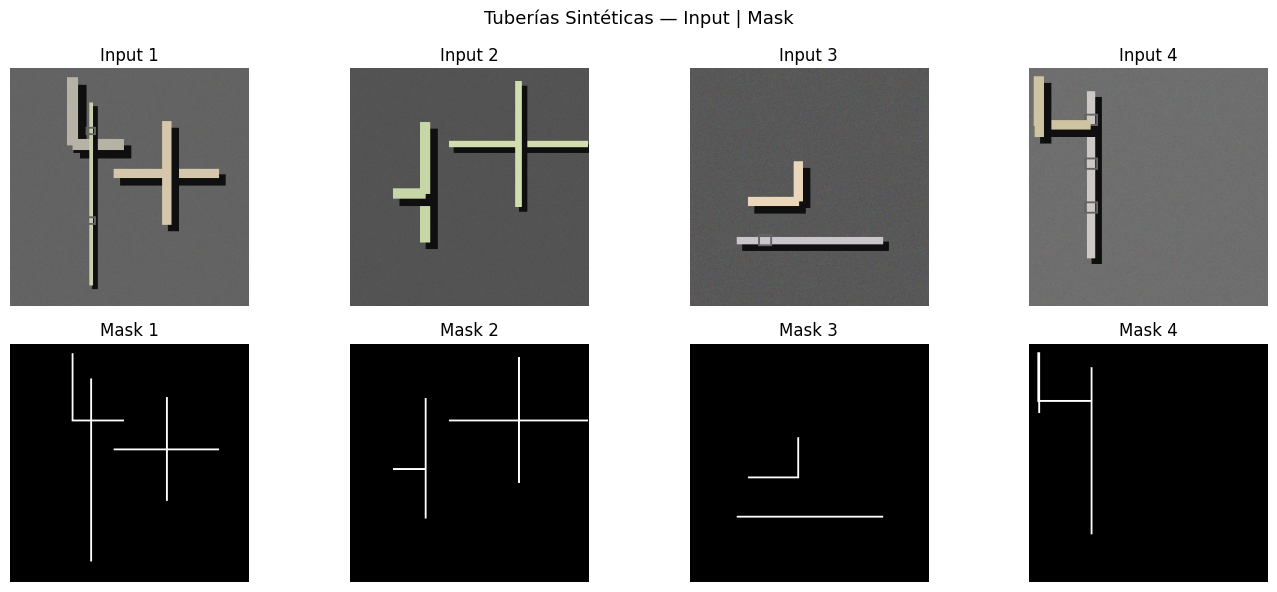

In [ ]:
SUBFASE  = 'tuberias_sinteticas'
FASE_DIR = os.path.join(DATASET_BASE, SUBFASE)

dir_input = os.path.join(FASE_DIR, 'train', 'inputs')
dir_mask  = os.path.join(FASE_DIR, 'train', 'masks')
muestras  = sorted(os.listdir(dir_input))[:4]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Tuberías Sintéticas — Input | Mask', fontsize=13)

for col, nombre in enumerate(muestras):
    img  = Image.open(os.path.join(dir_input, nombre))
    mask = Image.open(os.path.join(dir_mask,  nombre))
    axes[0][col].imshow(img);               axes[0][col].set_title(f'Input {col+1}'); axes[0][col].axis('off')
    axes[1][col].imshow(mask, cmap='gray'); axes[1][col].set_title(f'Mask {col+1}');  axes[1][col].axis('off')

plt.tight_layout()
plt.show()

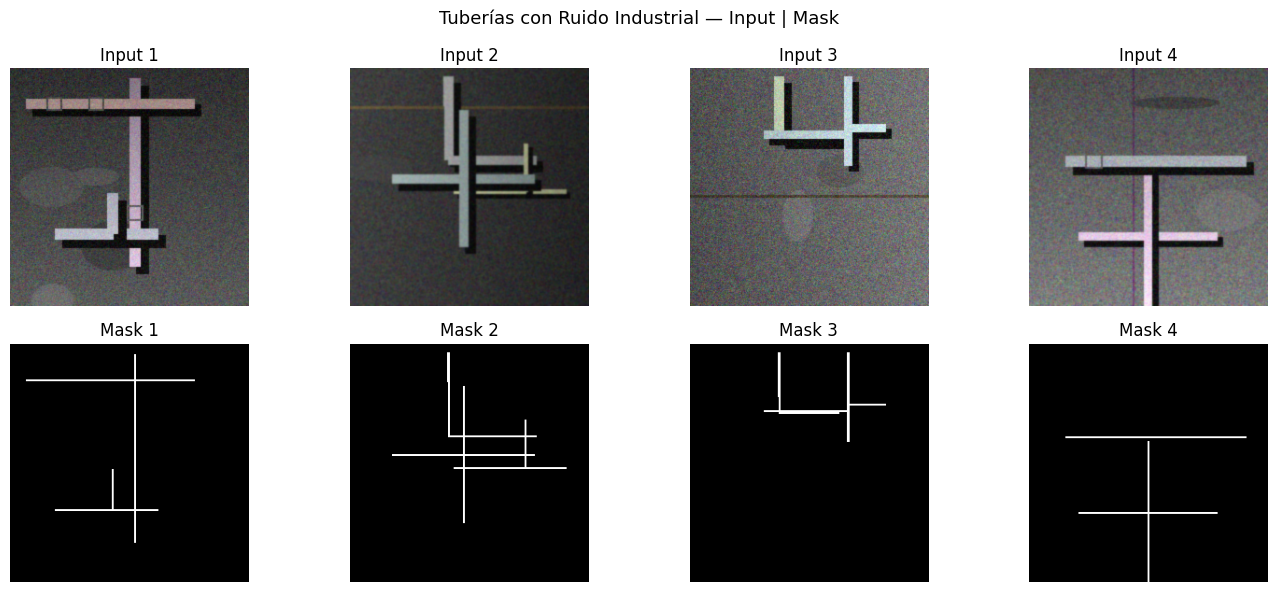

In [ ]:
SUBFASE  = 'tuberias_con_ruido'
FASE_DIR = os.path.join(DATASET_BASE, SUBFASE)

dir_input = os.path.join(FASE_DIR, 'train', 'inputs')
dir_mask  = os.path.join(FASE_DIR, 'train', 'masks')
muestras  = sorted(os.listdir(dir_input))[:4]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Tuberías con Ruido Industrial — Input | Mask', fontsize=13)

for col, nombre in enumerate(muestras):
    img  = Image.open(os.path.join(dir_input, nombre))
    mask = Image.open(os.path.join(dir_mask,  nombre))
    axes[0][col].imshow(img);               axes[0][col].set_title(f'Input {col+1}'); axes[0][col].axis('off')
    axes[1][col].imshow(mask, cmap='gray'); axes[1][col].set_title(f'Mask {col+1}');  axes[1][col].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
metadata = {
    'fase'      : 'fase3_entrenamiento',
    'img_size'  : IMG_SIZE,
    'train'     : TRAIN_N,
    'val'       : VAL_N,
    'test'      : TEST_N,
    'elementos' : ['tramo_recto', 'codo_90',
                   'conexion_T', 'conexion_cruz', 'red_tuberias'],
    'detalles'  : {
        'grosor_min'   : 4,
        'grosor_max'   : 12,
        'mask'         : 'eje central de tubería — línea de 2px',
        'sombras'      : True,
        'abrazaderas'  : True,
        'fondo'        : 'textura de pared con manchas',
        'ruido'        : ['gaussiano', 'blur', 'iluminacion_lateral',
                          'tubos_fondo', 'manchas_humedad'],
    },
    'notas' : 'Primera fase con geometría real de tuberías industriales.'
}

log_path = os.path.join(BASE, 'logs', 'fase3_entrenamiento_meta.json')
with open(log_path, 'w') as f:
    json.dump(metadata, f, indent=4)

total = (TRAIN_N + VAL_N + TEST_N) * 2
print(f"✅ Total generado Fase 3:")
print(f"   Tuberías sintéticas  : {TRAIN_N + VAL_N + TEST_N} imágenes")
print(f"   Tuberías con ruido   : {TRAIN_N + VAL_N + TEST_N} imágenes")
print(f"   Total                : {total} imágenes")
print(f"📋 Metadata guardada en logs/")

✅ Total generado Fase 3:
   Tuberías sintéticas  : 1400 imágenes
   Tuberías con ruido   : 1400 imágenes
   Total                : 2800 imágenes
📋 Metadata guardada en logs/
